Laenge: 912 
Breite: 624 
Dicke: 3.6
Auflager: Max
q = 0.08829000000000001
D = 287361419.06873614
weak formulation done
maxh: 40
pad_radius: 35
min w [mm] = -0.07710271499934972
Strech-faktor:  1000


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Vectors': False…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […

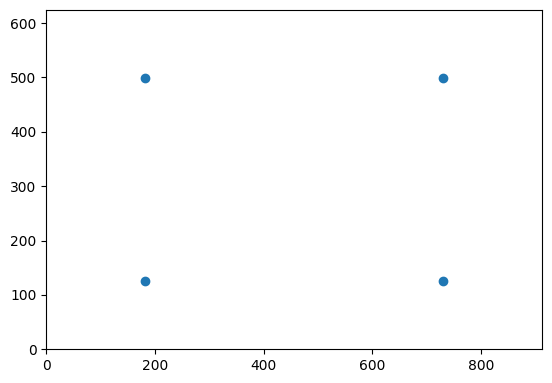

EW


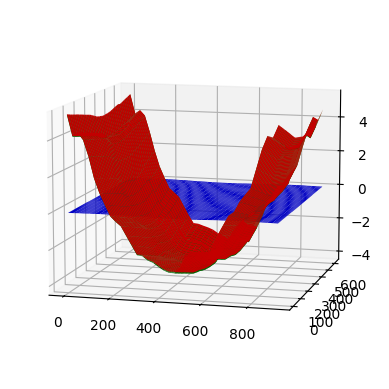

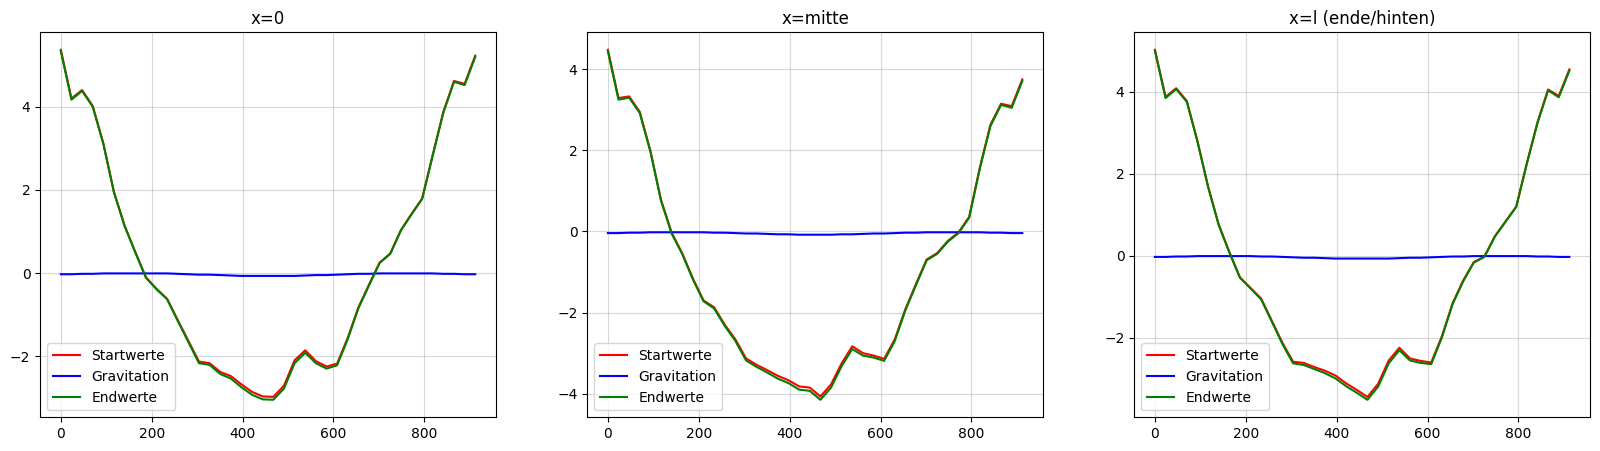

In [ ]:
import numpy as np
from math import sqrt
import import_ipynb

from ngsolve import *
from netgen.geom2d import SplineGeometry
import netgen.gui
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt
from ngsolve import x,y
from netgen.occ import *

import xyzFile_zusammenrechnen_EW   # greift auf *.py file zu, nicht auf *.ipynb

import pyvista as pv        # for complex 3D plot
pv.set_jupyter_backend('trame')

import import_ipynb
import ReissnerMindlin_Millimeter
# def ReissnerMindlin_GRAV(Lx,Ly,t,supports,factor=1,step=40,maxh=0.08):

"""
15.5
ReissnerMindlin ohne TDNNS
Auflager mit Kreisen und Federkraft
"""

'''
def ReissnerMindlin_GRAV(Lx,Ly,t,supports,factor=1,step=40,maxh=0.08):
    #region PARAMETER (MILLIMETER)
    E  = 70e6
    nu = 0.23
    rho = 2.5e-6
    g = 9810

    q = rho*t*g

    D = E*t**3/(12*(1-nu**2))      # Biegesteifigkeit
    G = E/(2*(1+nu))
    ks = 5/6                       # Schubkorrektur
    S = ks*G*t                     # Schubsteifigkeit
    A = E*t/(1-nu**2)              # Membransteifigkeit

    print("q =", q)
    print("D =", D)
    #endregion

    
    shape = MoveTo(0,0).Rectangle(Lx,Ly).Face()
    shape.edges.name="free"

    rect = shape 
    geo = OCCGeometry(rect,dim=2)
    mesh = Mesh(geo.GenerateMesh(maxh=maxh))
    mesh.Curve(3)

    # -----------------------------
    # FEM Räume
    # w      = Durchbiegung
    # beta   = Rotationen beta_x, beta_y
    # -----------------------------
    order = 2
    Vw = H1(mesh, order=order)
    Vb = VectorH1(mesh, order=order)

    X = FESpace([Vw, Vb])

    u, beta = X.TrialFunction()
    v, eta  = X.TestFunction()

    gf = GridFunction(X)
    w, rot = gf.components
    #endregion
    pad_radius = 15          # 35 mm Lagerpad
    k_support = 5e4            # N/m³, vertikale Feder pro Fläche

    # x = mesh.MaterialCF({"default": x})
    # y = mesh.MaterialCF({"default": y})
    from ngsolve import x,y

    support_cf = 0
    for xs, ys in supports:
        r2 = (x-xs)*(x-xs) + (y-ys)*(y-ys)
        support_cf += IfPos(pad_radius*pad_radius-r2, 1, 0)

    #region FEM
    # -----------------------------
    # Lineares Reissner-Mindlin Modell
    # -----------------------------
    def eps_bending(b):
        return Sym(Grad(b))

    def inner_sym(A,B):
        return InnerProduct(A,B)

    a = BilinearForm(X, symmetric=True)

    # Biegung
    a += D * (
        (1-nu)*inner_sym(eps_bending(beta), eps_bending(eta))
        + nu*Trace(eps_bending(beta))*Trace(eps_bending(eta))
    ) * dx

    # Schub: grad(w)-beta
    a += S * InnerProduct(Grad(u)-beta, Grad(v)-eta) * dx

    # Punkt-/Pad-Auflager
    a += k_support * support_cf * u*v * dx

    f = LinearForm(X)
    f += -q * v * dx

    a.Assemble()
    f.Assemble()
    gf.vec.data = a.mat.Inverse(X.FreeDofs(), inverse="sparsecholesky") * f.vec

    print("linear min w [mm] =", min(w.vec.FV().NumPy()))

    Draw(factor*w, mesh,deformation=True,euler_angles=[-60,5,30])
    print("Strech-faktor: ",factor)
    #endregion

    #region PLOTTEN
    import numpy as np
    #erzeugt gitter für gewünschte werte
    # x_points = np.round(np.linspace(0,l, step)).astype(int)
    # y_points = np.round(np.linspace(0,b, step)).astype(int)
    x_points_ungerundet = np.linspace(0,Lx, step)
    x_points = np.round(x_points_ungerundet, 2)
    y_points_ungerundet = np.linspace(0,Ly, step)
    y_points = np.round(y_points_ungerundet, 2)
    # print(x_points_ungerundet)
    # print(x_points)

    X_mesh, Y_mesh = np.meshgrid(x_points, y_points)
    #print(x_points)
    #speichert (x,y,z) in gravitation_matrix für alle (x,y) in X_mesh,Y_mesh
    gravitation_matrix = np.zeros((step, step),dtype=object)
    for i in range(step):
        for j in range(step):
            try:
                z_eintrag = w(X_mesh[i, j], Y_mesh[i, j])
            except:
                z_eintrag = 0
            gravitation_matrix[i, j] = (float(X_mesh[i,j]), float(Y_mesh[i,j]), z_eintrag)

    #*.xyz file erstellen
    filename_GRAV = f"xyzFiles/{t}mm_gravitation.xyz"
    with open(filename_GRAV, "w") as f:
        for i in range(step):
            for j in range(step):
                x, y, w = gravitation_matrix[i, j]
                f.write(f"{x:.2f}\t{y:.2f}\t{w:.2f}\n")

    import matplotlib.pyplot as plt

    xs = [x[0] for x in supports]
    ys = [x[1] for x in supports]
    plt.scatter(xs, ys)
    plt.xlim(0, Lx)
    plt.ylim(0, Ly)

    plt.gca().set_aspect('equal', adjustable='box')  # optional: gleiche Skalierung
    plt.show()
    #endregion
    return filename_GRAV
'''

if __name__ == "__main__":
    t = 3.6
    Vorzeichen = "Max"      #Vorzeichen bestimmt, ob MW und Grav-W addiert oder subtrahiert werden um EW zu berechnen
    # MESSWöERTE
    #filename_MW = f"{t}mm_messwerte.xyz"
    filename_MW = "xyzFiles/2026-04-05_12h14m20s_scan25-3.6.xyz"
    data_messwerte = np.loadtxt(filename_MW)

    # step wird aus Messwerte-File entnommen
    step_square = len(data_messwerte[:,0])
    if sqrt(step_square)%1 != 0:
        raise ValueError("the Length of the *.xyz-File is not suitable, it should be step*step")

    step = int(sqrt(step_square))

    # Laenge/Breite wird aus Messwerte-File entnommen
    L = int(data_messwerte[-1,0])   #achtung: -1 steht hier für die letzte Zeile, 0 für den x eintrag, 1 für den y eintrag; Werte des Files in Millimeter
    B = int(data_messwerte[-1,1])
    print("Laenge:",L,"\nBreite:",B,"\nDicke:",t)
    print("Auflager:",Vorzeichen)

    # supports = [(0,0),(0,B),(L,0),(L,B)]
    # supports = [(L/2 - 10, B/2 - 10), (L/2 + 10, B/2 - 10), (L/2 - 10, B/2 + 10), (L/2 + 10, B/2 + 10)]
    supports = [(8/10 * L, 8/10 * B), (8/10 * L, 2/10 * B), (2/10 * L, 8/10 * B), (2/10 * L, 2/10 * B)]

    factor = 1000
    step = 40
    maxh = 40

    #Gravitation: Auswirkung berechnen (+ ngolve plot + xyz-File für Grav)
    filename_GRAV = ReissnerMindlin_Millimeter.ReissnerMindlin_GRAV_Punkte(L,B,t,supports,factor,step,maxh)

    #Messwerte und Grav-Werte zusammenrechnen und plotten (+ xyz-File für EW)
    print("EW")
    filename_EW = xyzFile_zusammenrechnen_EW.plotten(L,B,t,step,filename_MW,filename_GRAV,Vorzeichen)

